# XLSX 시계열 정밀 EDA 노트북

이 노트북은 Xsens `.xlsx` 시계열 데이터를 시각화 중심으로 정밀 분석하기 위한 템플릿입니다.

핵심 목표:
1. 사용 가능한 시트와 채널 구조를 빠르게 파악
2. 재사용 가능한 시각화 함수 확보
3. 그룹/속도 조건별 비교 시각화 수행


## 분석 범위

- 데이터 루트: `data/`
- 파일 타입: 참가자 gait trial `.xlsx`
- 1순위 시트:
  - `Joint Angles ZXY`
  - `Segment Position`
  - `Center of Mass`
  - `Sensor Free Acceleration`
- 2순위 시트:
  - `Segment Velocity`
  - `Segment Orientation - Euler`


In [49]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

# 기본 figure 크기 설정 (필요 시 여기만 수정하면 전체 플롯 크기 일괄 변경)
FIG_WIDE = (16, 4.8)
FIG_TALL = (16, 7.6)
FIG_HEATMAP = (12, 5)
FIG_OVERLAY = (16, 8)


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start


def setup_korean_font() -> str | None:
    # 한글 렌더링용 폰트 후보를 순서대로 시도
    font_candidates = [
        "Malgun Gothic",
        "NanumGothic",
        "NanumBarunGothic",
        "AppleGothic",
        "DejaVu Sans",
    ]
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    for font_name in font_candidates:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_name
    return None


ROOT = find_repo_root(Path.cwd())
DATA_DIR = ROOT / "data"
selected_font = setup_korean_font()
print("ROOT:", ROOT)
print("선택된 폰트:", selected_font or "기본 폰트")


ROOT: C:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking
선택된 폰트: Malgun Gothic


In [50]:
GROUP_ORDER = ["Healthy adults", "Healthy adolescents", "ACLD", "ACLR"]
PACE_ORDER = ["slow", "normal", "fast"]


def collect_xlsx_trials(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    # data/ 하위의 모든 xlsx trial 파일을 수집하고 pace를 파일명 기반으로 추론
    rows = []
    for group_dir in sorted([p for p in data_dir.iterdir() if p.is_dir()]):
        group_name = group_dir.name
        for participant_dir in sorted([p for p in group_dir.iterdir() if p.is_dir()]):
            participant = participant_dir.name
            for xlsx_path in sorted(participant_dir.glob("**/*.xlsx")):
                lower = str(xlsx_path).lower()
                if "normal" in lower or "nrml" in lower:
                    pace = "normal"
                elif "slow" in lower:
                    pace = "slow"
                elif "fast" in lower:
                    pace = "fast"
                else:
                    pace = "unknown"
                rows.append(
                    {
                        "group": group_name,
                        "participant": participant,
                        "pace_condition": pace,
                        "file_path": xlsx_path,
                        "file_name": xlsx_path.name,
                    }
                )
    return pd.DataFrame(rows)


trials = collect_xlsx_trials()
print("전체 xlsx trial 수:", len(trials))
trials.head()


전체 xlsx trial 수: 1090


,group,participant,pace_condition,file_path,file_name
0,ACLD,ACLD1,fast,C:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\...,FAST-001.xlsx
1,ACLD,ACLD1,fast,C:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\...,FAST-002.xlsx
2,ACLD,ACLD1,normal,C:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\...,nrml-001.xlsx
3,ACLD,ACLD1,normal,C:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\...,nrml-002.xlsx
4,ACLD,ACLD1,normal,C:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\...,nrml-003.xlsx


In [51]:
coverage = (
    trials.groupby(["group", "pace_condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=GROUP_ORDER)
)
coverage


pace_condition,fast,normal,slow
group,,,
Healthy adults,77,83,78
Healthy adolescents,131,86,87
ACLD,116,121,109
ACLR,67,68,67


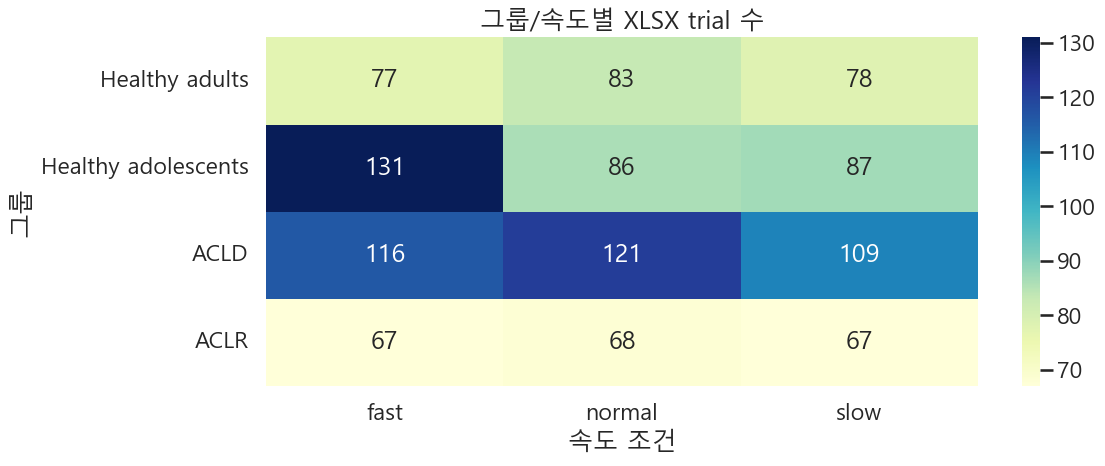

In [52]:
plt.figure(figsize=FIG_HEATMAP)
sns.heatmap(coverage, annot=True, fmt="d", cmap="YlGnBu")
plt.title("그룹/속도별 XLSX trial 수")
plt.xlabel("속도 조건")
plt.ylabel("그룹")
plt.tight_layout()
plt.show()


In [53]:
def select_representative_trials(trials_df: pd.DataFrame, preferred_pace: str = "normal") -> pd.DataFrame:
    # 그룹별 대표 trial 1개 선택 (normal 우선)
    rows = []
    for group_name in GROUP_ORDER:
        subset = trials_df[trials_df["group"] == group_name].copy()
        if subset.empty:
            continue
        preferred = subset[subset["pace_condition"] == preferred_pace]
        chosen = preferred.iloc[0] if not preferred.empty else subset.iloc[0]
        rows.append(chosen)
    return pd.DataFrame(rows).reset_index(drop=True)


sample_trials = select_representative_trials(trials, preferred_pace="normal")
sample_trials[["group", "participant", "pace_condition", "file_name"]]


,group,participant,pace_condition,file_name
0,Healthy adults,HA1,normal,nrml-001.xlsx
1,Healthy adolescents,HK1,normal,nrml-001.xlsx
2,ACLD,ACLD1,normal,nrml-001.xlsx
3,ACLR,ACLR10,normal,NRML-001.xlsx


In [54]:
rep_file = Path(sample_trials.iloc[0]["file_path"])
xl = pd.ExcelFile(rep_file)
sheet_info = pd.DataFrame({"sheet_name": xl.sheet_names})
sheet_info


,sheet_name
0,General Information
1,Markers
2,Segment Orientation - Quat
3,Segment Orientation - Euler
4,Segment Position
5,Segment Velocity
6,Segment Acceleration
7,Segment Angular Velocity
8,Segment Angular Acceleration
9,Joint Angles ZXY


In [55]:
def inspect_sheet_structure(xlsx_path: Path, sheet_name: str, nrows: int = 3) -> pd.DataFrame:
    # 시트의 컬럼명, 미리보기 결측 개수, dtype을 빠르게 확인
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name, nrows=nrows)
    out = pd.DataFrame(
        {
            "컬럼명": df.columns.astype(str),
            "미리보기_non_null_개수": [df[c].notna().sum() for c in df.columns],
            "dtype_미리보기": [str(df[c].dtype) for c in df.columns],
        }
    )
    return out


inspect_sheet_structure(rep_file, "Joint Angles ZXY").head(12)


,컬럼명,미리보기_non_null_개수,dtype_미리보기
0,Frame,3,int64
1,L5S1 Lateral Bending,3,int64
2,L5S1 Axial Bending,3,int64
3,L5S1 Flexion/Extension,3,float64
4,L4L3 Lateral Bending,3,int64
5,L4L3 Axial Rotation,3,int64
6,L4L3 Flexion/Extension,3,float64
7,L1T12 Lateral Bending,3,int64
8,L1T12 Axial Rotation,3,int64
9,L1T12 Flexion/Extension,3,float64


## 데이터 로딩 헬퍼

In [56]:
def read_trial_sheets(xlsx_path: Path) -> dict:
    # 분석 우선순위가 높은 시트만 묶어서 로딩
    return {
        "joint_zxy": pd.read_excel(xlsx_path, sheet_name="Joint Angles ZXY"),
        "segment_position": pd.read_excel(xlsx_path, sheet_name="Segment Position"),
        "com": pd.read_excel(xlsx_path, sheet_name="Center of Mass"),
        "sensor_free_accel": pd.read_excel(xlsx_path, sheet_name="Sensor Free Acceleration"),
        "segment_velocity": pd.read_excel(xlsx_path, sheet_name="Segment Velocity"),
        "segment_orientation_euler": pd.read_excel(xlsx_path, sheet_name="Segment Orientation - Euler"),
    }


def get_lr_cols(df: pd.DataFrame, token_right: str, token_left: str, axis: str) -> tuple[str | None, str | None]:
    # 좌/우 컬럼명이 모두 있는지 확인해 안전하게 반환
    right_col = f"{token_right} {axis}"
    left_col = f"{token_left} {axis}"
    return (right_col if right_col in df.columns else None, left_col if left_col in df.columns else None)


## 시각화 헬퍼

In [57]:
def plot_joint_knee_ankle(joint_df: pd.DataFrame, title_prefix: str, frame_start: int | None = None, frame_end: int | None = None):
    # 무릎/발목 관절각을 우선 시각화
    df = joint_df.copy()
    if frame_start is not None and frame_end is not None:
        df = df[(df["Frame"] >= frame_start) & (df["Frame"] <= frame_end)]

    candidates = [
        "Right Knee Flexion/Extension",
        "Left Knee Flexion/Extension",
        "Right Ankle Dorsiflexion/Plantarflexion",
        "Left Ankle Dorsiflexion/Plantarflexion",
    ]
    selected = [c for c in candidates if c in df.columns]
    if not selected:
        raise KeyError("Joint Angles ZXY에 무릎/발목 컬럼이 없습니다.")

    ax = df.set_index("Frame")[selected].plot(figsize=FIG_WIDE, linewidth=1.35)
    ax.set_title(f"{title_prefix} - 관절각(무릎/발목)")
    ax.set_xlabel("Frame")
    ax.set_ylabel("각도")
    ax.legend(title="채널", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    plt.tight_layout(rect=[0, 0, 0.83, 1])
    plt.show()


def plot_sensor_free_accel_feet(acc_df: pd.DataFrame, title_prefix: str, frame_start: int | None = None, frame_end: int | None = None):
    # 좌우 발의 자유가속도(중력 제거)를 비교 시각화
    df = acc_df.copy()
    if frame_start is not None and frame_end is not None:
        df = df[(df["Frame"] >= frame_start) & (df["Frame"] <= frame_end)]

    cols = []
    for axis in ["x", "y", "z"]:
        right, left = get_lr_cols(df, "Right Foot", "Left Foot", axis)
        if right:
            cols.append(right)
        if left:
            cols.append(left)
    if not cols:
        raise KeyError("Sensor Free Acceleration에 Right/Left Foot x,y,z 컬럼이 없습니다.")

    ax = df.set_index("Frame")[cols].plot(figsize=FIG_WIDE, linewidth=1.15, alpha=0.85)
    ax.set_title(f"{title_prefix} - 자유가속도(좌우 발)")
    ax.set_xlabel("Frame")
    ax.set_ylabel("가속도")
    ax.legend(title="채널", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    plt.tight_layout(rect=[0, 0, 0.83, 1])
    plt.show()


def plot_com_signals(com_df: pd.DataFrame, title_prefix: str, frame_start: int | None = None, frame_end: int | None = None):
    # CoM 위치/속도 변화를 한 번에 확인
    df = com_df.copy()
    if frame_start is not None and frame_end is not None:
        df = df[(df["Frame"] >= frame_start) & (df["Frame"] <= frame_end)]

    cols = [c for c in ["CoM pos x", "CoM pos y", "CoM pos z", "CoM vel x", "CoM vel y", "CoM vel z"] if c in df.columns]
    if not cols:
        raise KeyError("Center of Mass 시트에 CoM position/velocity 컬럼이 없습니다.")

    ax = df.set_index("Frame")[cols].plot(figsize=FIG_WIDE, linewidth=1.2)
    ax.set_title(f"{title_prefix} - 질량중심(CoM) 위치/속도")
    ax.set_xlabel("Frame")
    ax.set_ylabel("값")
    ax.legend(title="채널", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    plt.tight_layout(rect=[0, 0, 0.83, 1])
    plt.show()


def plot_pelvis_and_feet_position(seg_df: pd.DataFrame, title_prefix: str, frame_start: int | None = None, frame_end: int | None = None):
    # 골반 + 양측 발 위치를 같이 확인해 보행 궤적 감각을 잡음
    df = seg_df.copy()
    if frame_start is not None and frame_end is not None:
        df = df[(df["Frame"] >= frame_start) & (df["Frame"] <= frame_end)]

    cols = []
    for segment_name in ["Pelvis", "Right Foot", "Left Foot"]:
        for axis in ["x", "y", "z"]:
            col = f"{segment_name} {axis}"
            if col in df.columns:
                cols.append(col)
    if not cols:
        raise KeyError("Segment Position에 Pelvis/Foot 위치 컬럼이 없습니다.")

    ax = df.set_index("Frame")[cols].plot(figsize=FIG_WIDE, linewidth=1.1)
    ax.set_title(f"{title_prefix} - Segment Position(골반/발)")
    ax.set_xlabel("Frame")
    ax.set_ylabel("위치")
    ax.legend(title="채널", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    plt.tight_layout(rect=[0, 0, 0.83, 1])
    plt.show()


## 예시: 대표 trial 정밀 시각화

Healthy adults / HA1 / normal - nrml-001.xlsx


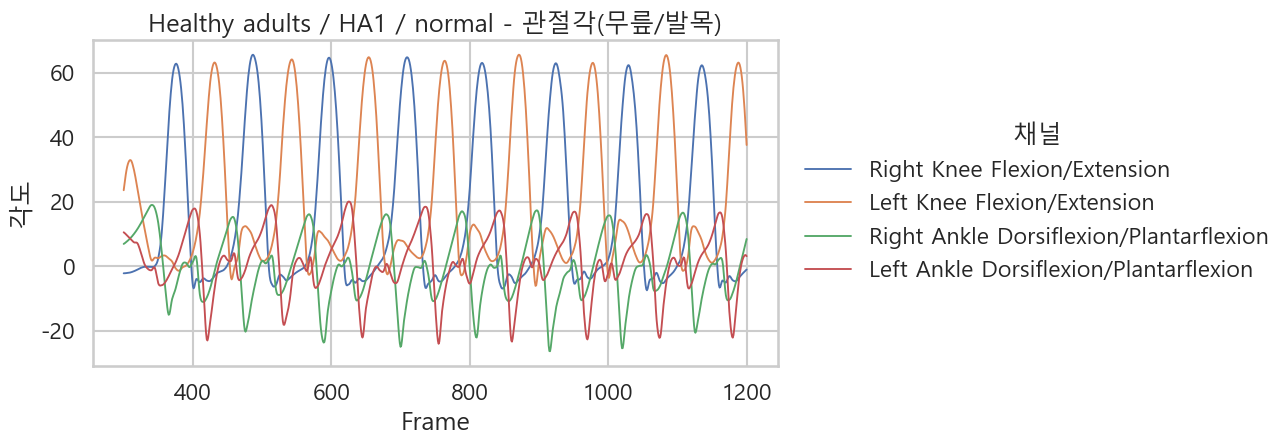

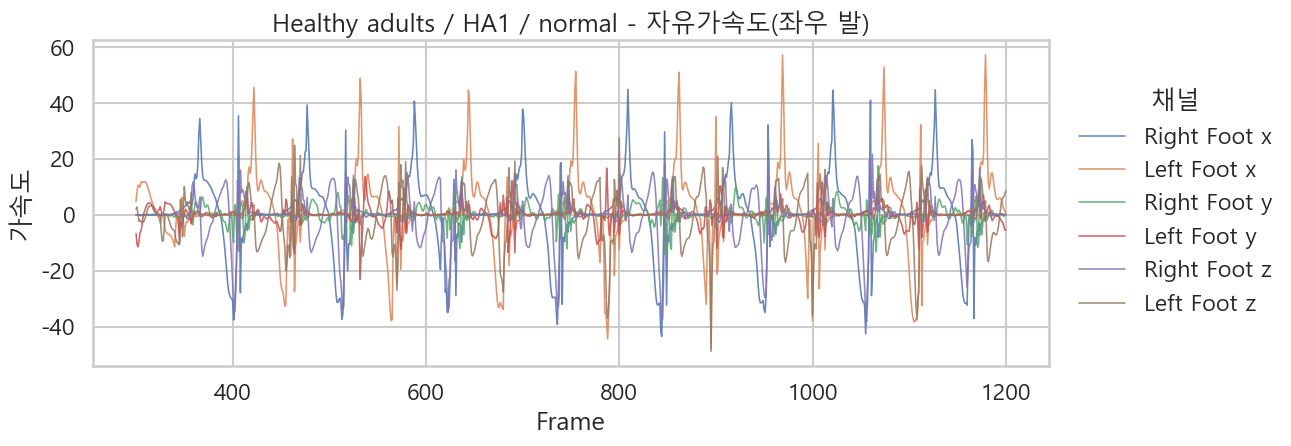

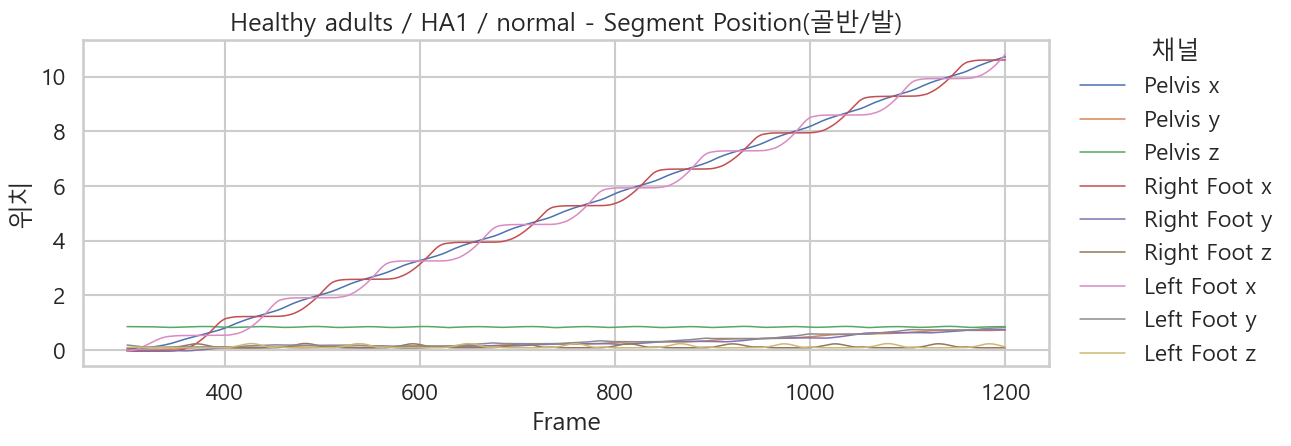

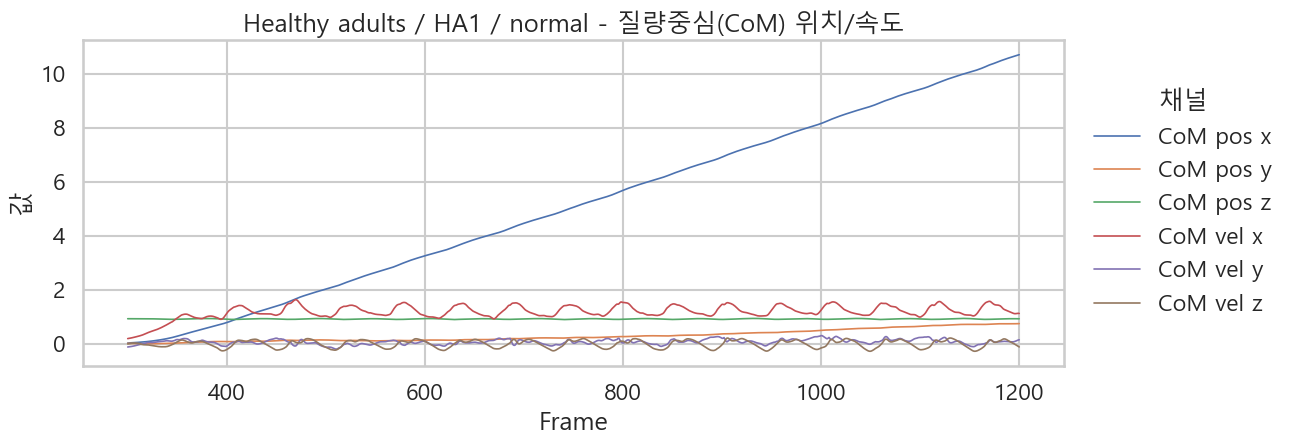

Healthy adolescents / HK1 / normal - nrml-001.xlsx


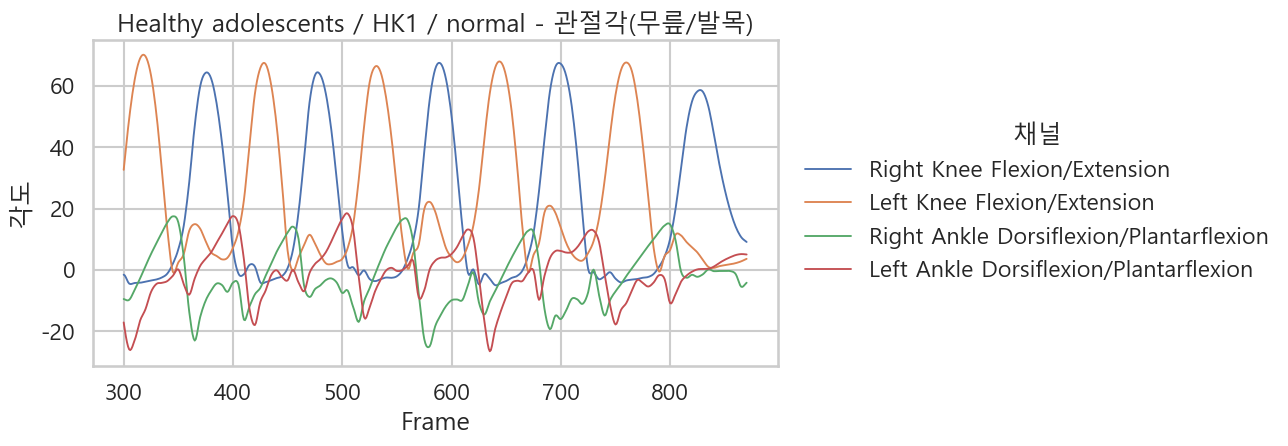

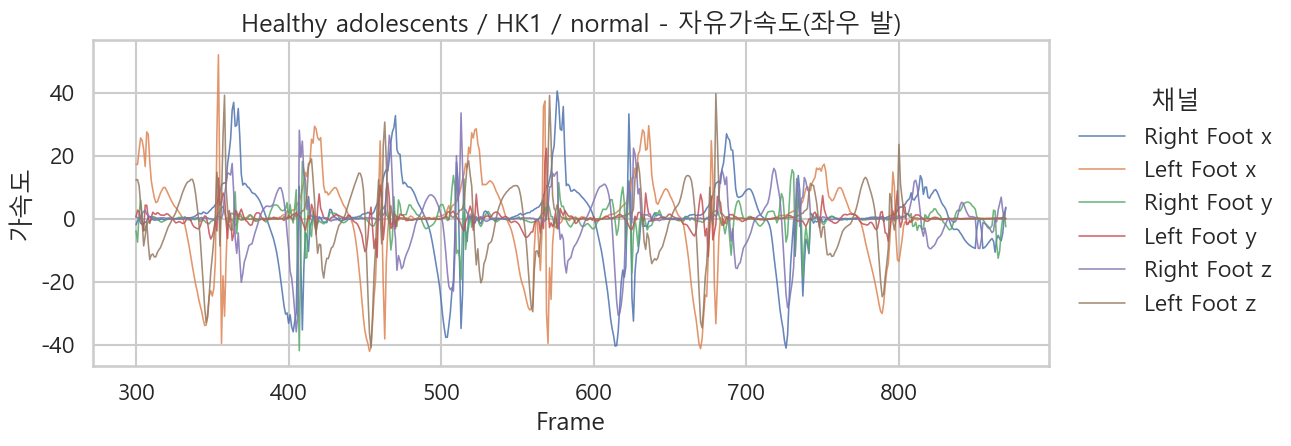

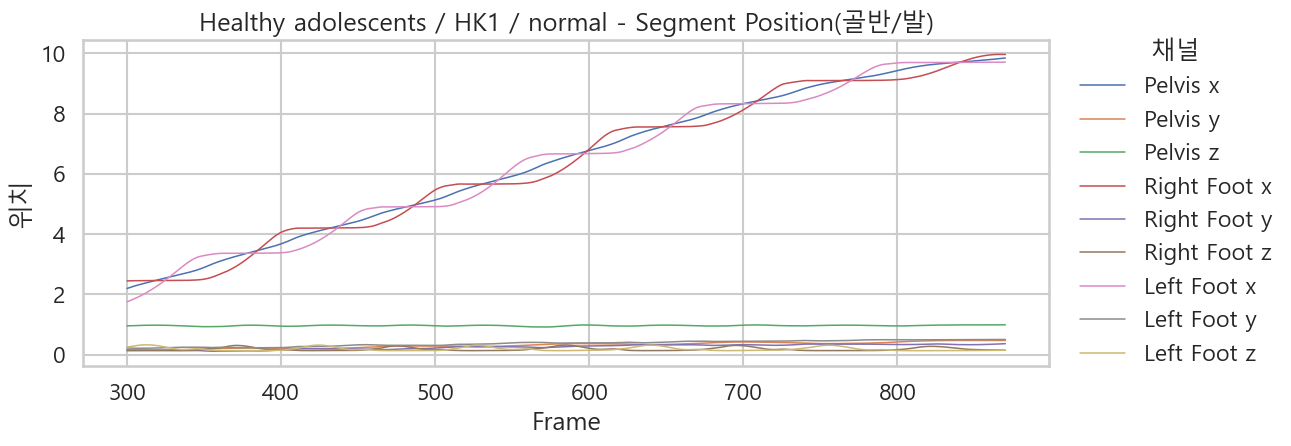

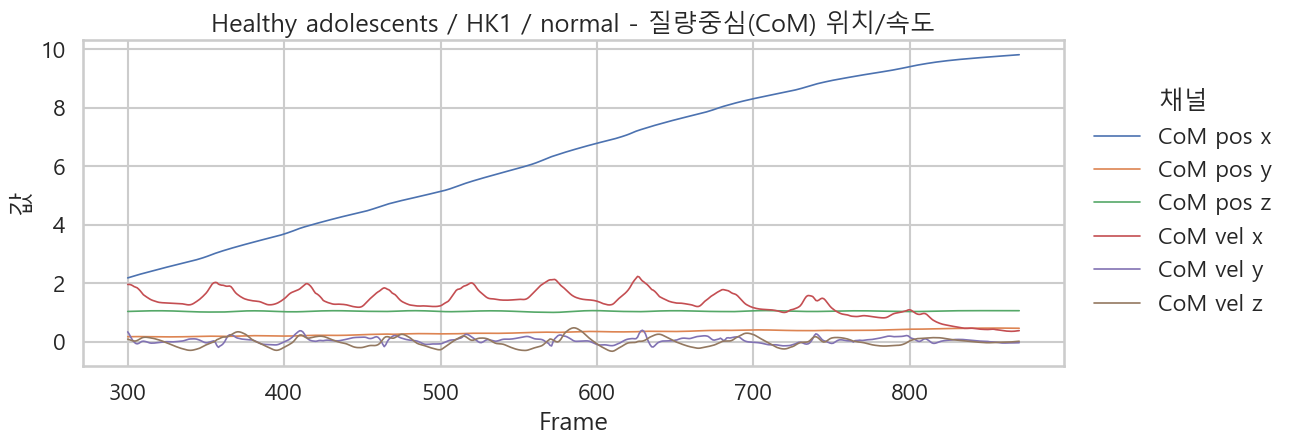

ACLD / ACLD1 / normal - nrml-001.xlsx


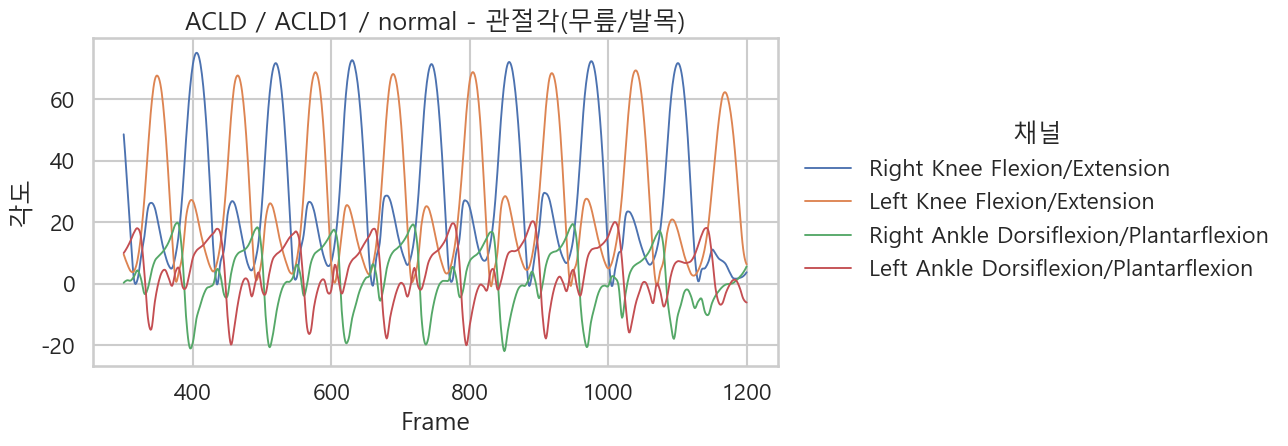

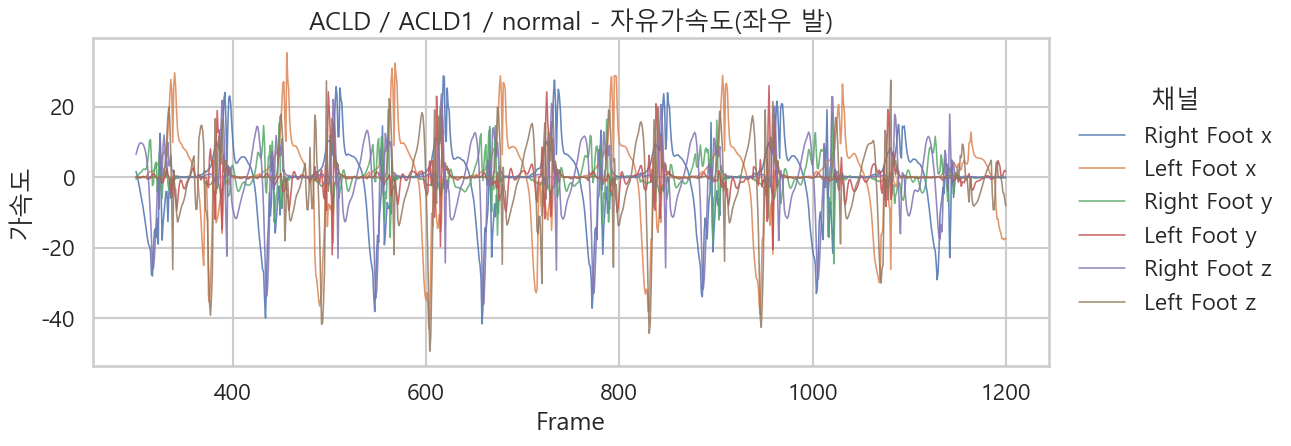

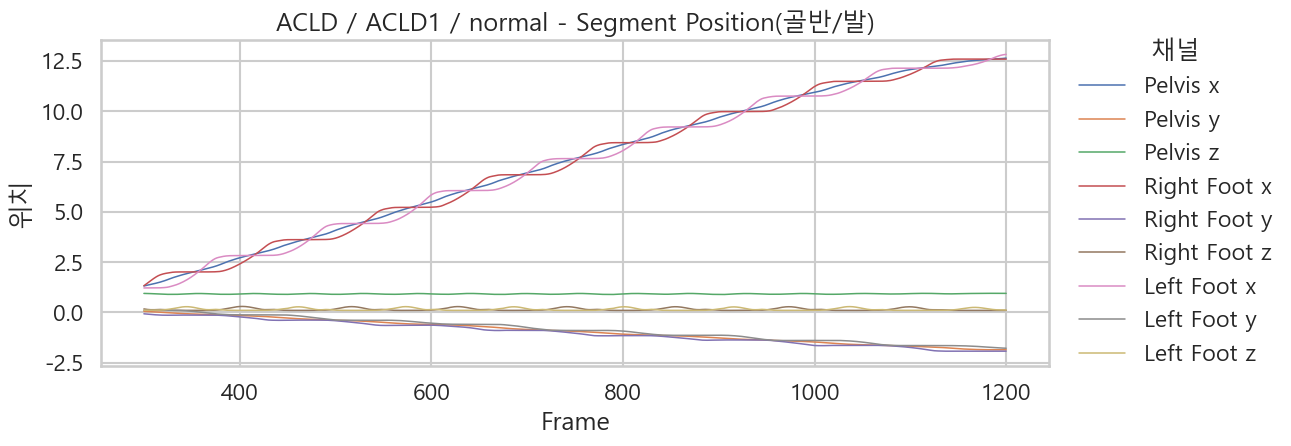

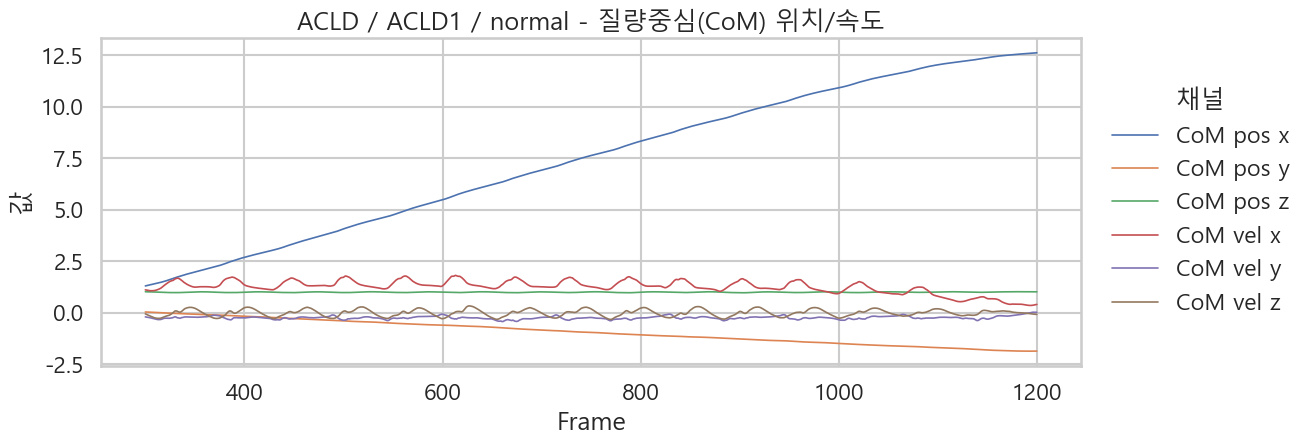

ACLR / ACLR10 / normal - NRML-001.xlsx


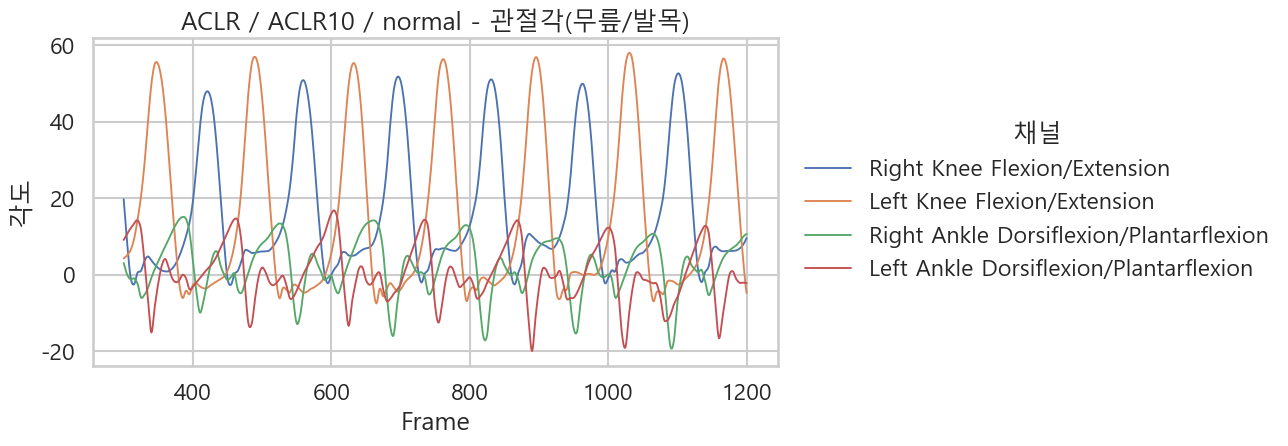

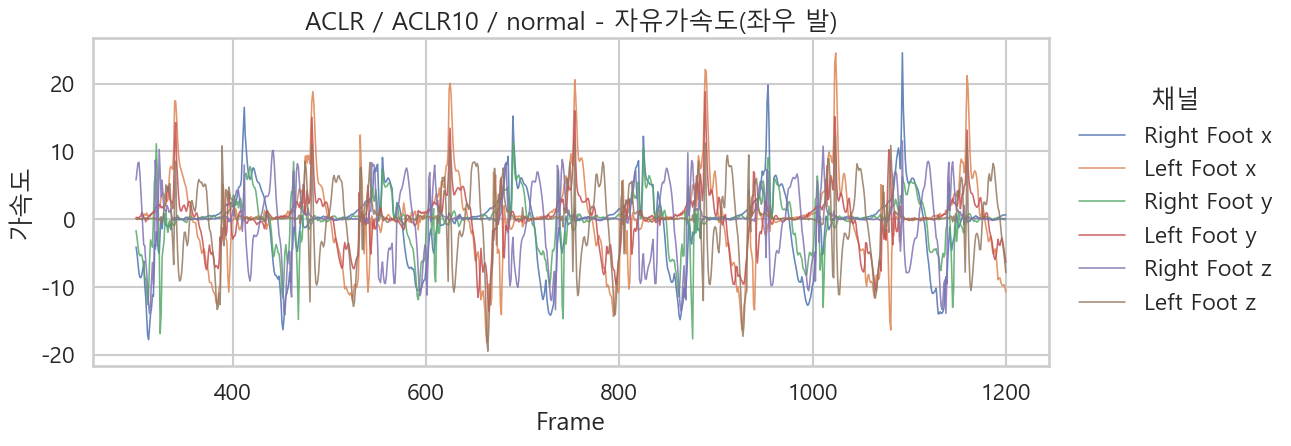

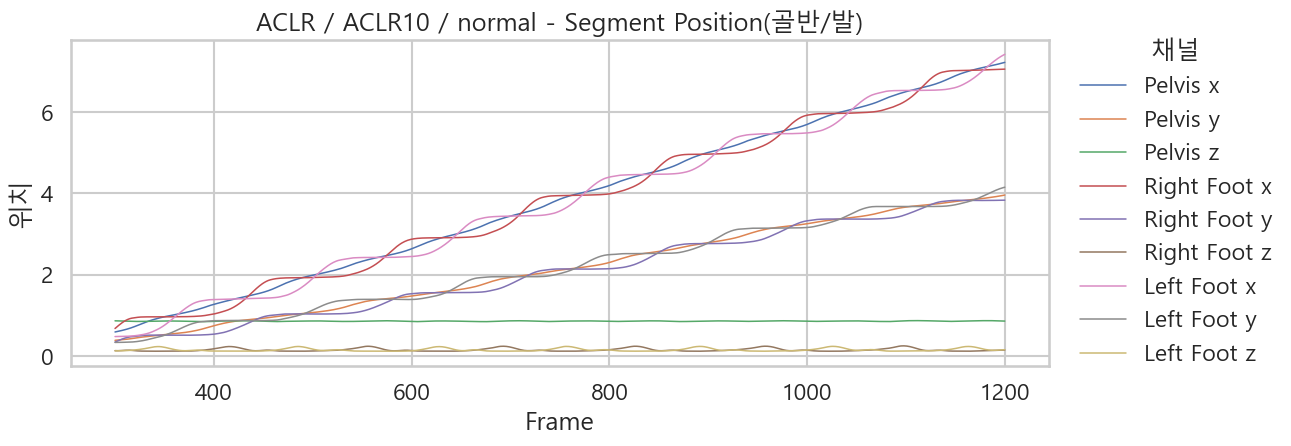

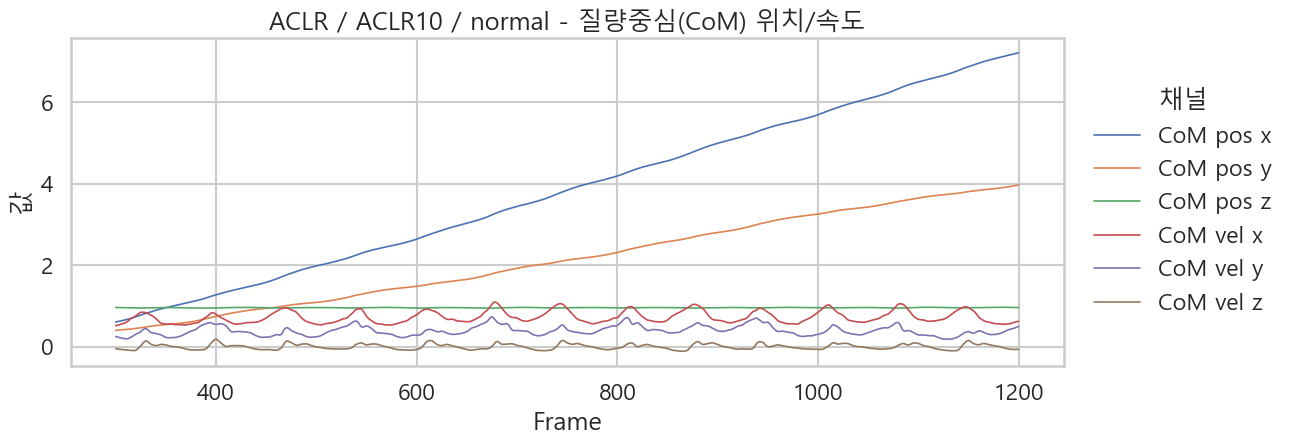

In [58]:
for _, row in sample_trials.iterrows():
    title_prefix = f"{row['group']} / {row['participant']} / {row['pace_condition']}"
    sheet_data = read_trial_sheets(Path(row["file_path"]))

    print(title_prefix, "-", Path(row["file_path"]).name)
    plot_joint_knee_ankle(sheet_data["joint_zxy"], title_prefix, frame_start=300, frame_end=1200)
    plot_sensor_free_accel_feet(sheet_data["sensor_free_accel"], title_prefix, frame_start=300, frame_end=1200)
    plot_pelvis_and_feet_position(sheet_data["segment_position"], title_prefix, frame_start=300, frame_end=1200)
    plot_com_signals(sheet_data["com"], title_prefix, frame_start=300, frame_end=1200)


## 동일 참가자 속도별 Overlay

In [59]:
def get_participant_trials(trials_df: pd.DataFrame, group_name: str, participant: str) -> pd.DataFrame:
    # 같은 참가자의 slow/normal/fast trial을 속도 순서로 정렬
    subset = trials_df[(trials_df["group"] == group_name) & (trials_df["participant"] == participant)].copy()
    subset["pace_rank"] = subset["pace_condition"].map({"slow": 0, "normal": 1, "fast": 2, "unknown": 99})
    return subset.sort_values("pace_rank")


target = sample_trials.iloc[0]
overlay_trials = get_participant_trials(trials, target["group"], target["participant"])
overlay_trials[["group", "participant", "pace_condition", "file_name"]]


,group,participant,pace_condition,file_name
858,Healthy adults,HA1,slow,SLOW-001.xlsx
859,Healthy adults,HA1,slow,SLOW-002.xlsx
860,Healthy adults,HA1,slow,SLOW-003.xlsx
855,Healthy adults,HA1,normal,nrml-001.xlsx
856,Healthy adults,HA1,normal,nrml-002.xlsx
857,Healthy adults,HA1,normal,nrml-003.xlsx
852,Healthy adults,HA1,fast,FAST-001.xlsx
853,Healthy adults,HA1,fast,FAST-002.xlsx
854,Healthy adults,HA1,fast,FAST-003.xlsx


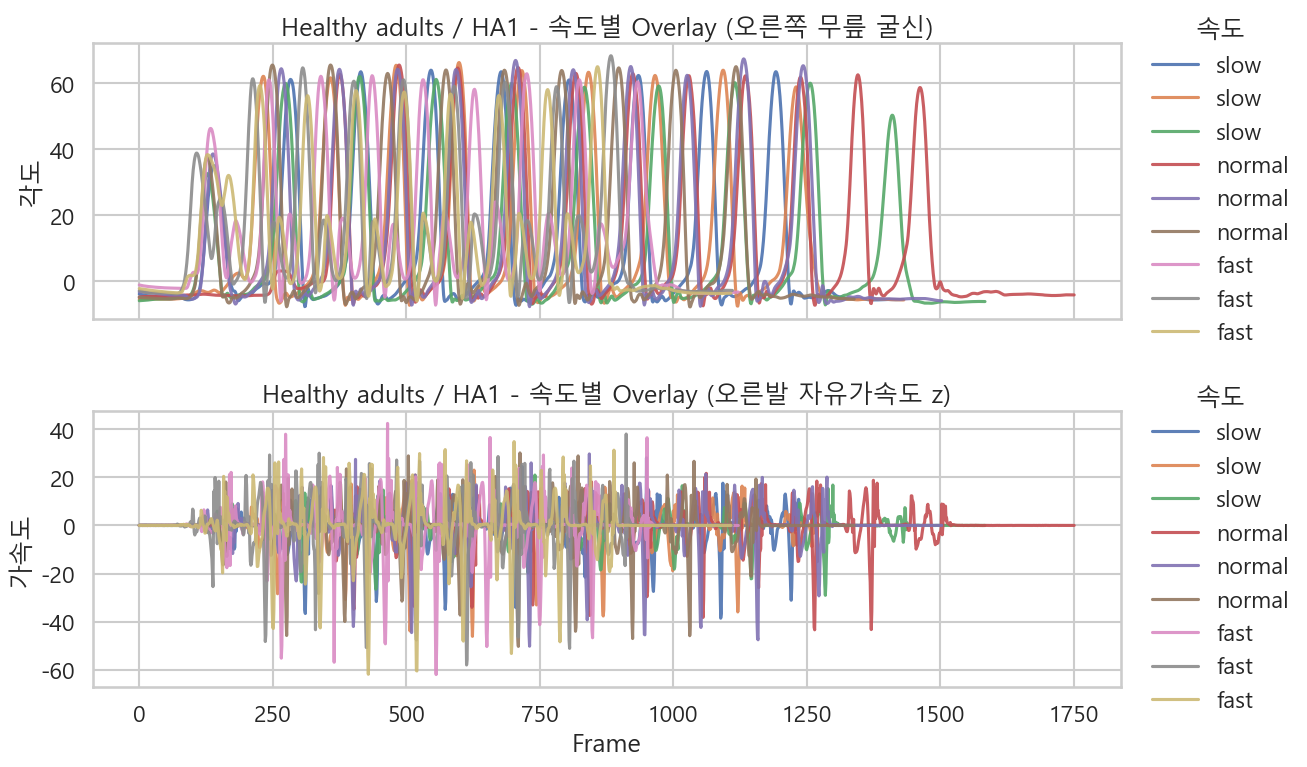

In [60]:
fig, axes = plt.subplots(2, 1, figsize=FIG_OVERLAY, sharex=True)

for _, row in overlay_trials.iterrows():
    path = Path(row["file_path"])
    pace = row["pace_condition"]
    joint = pd.read_excel(path, sheet_name="Joint Angles ZXY")
    acc = pd.read_excel(path, sheet_name="Sensor Free Acceleration")

    if "Right Knee Flexion/Extension" in joint.columns:
        j = joint[["Frame", "Right Knee Flexion/Extension"]].set_index("Frame")
        axes[0].plot(j.index, j["Right Knee Flexion/Extension"], label=f"{pace}", alpha=0.9)

    if "Right Foot z" in acc.columns:
        a = acc[["Frame", "Right Foot z"]].set_index("Frame")
        axes[1].plot(a.index, a["Right Foot z"], label=f"{pace}", alpha=0.9)

axes[0].set_title(f"{target['group']} / {target['participant']} - 속도별 Overlay (오른쪽 무릎 굴신)")
axes[0].set_ylabel("각도")
axes[0].legend(title="속도", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

axes[1].set_title(f"{target['group']} / {target['participant']} - 속도별 Overlay (오른발 자유가속도 z)")
axes[1].set_ylabel("가속도")
axes[1].set_xlabel("Frame")
axes[1].legend(title="속도", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()


## 다음 개선 포인트

1. heel-strike 기반 gait-cycle 정규화 추가
2. 자유가속도 peak 자동 검출 추가
3. 그룹 평균 ± 표준편차 envelope 추가
4. 자기장/센서 orientation 기반 센서 품질 점검 추가
5. `FIG_WIDE`, `FIG_TALL`, `FIG_OVERLAY` 값 조정으로 레이아웃 튜닝
